# Three-source Nash-MTL autoencoder


In [28]:
%matplotlib inline
import os, sys, importlib
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT/'src'/'lss').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT/'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT/'src'))
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import torch
from graph_utils import directional_side_indices_from_box
import lss.latent.training as _latent_training
import lss.latent.experiment as _latent_experiment
importlib.reload(_latent_training)
importlib.reload(_latent_experiment)
from lss.latent.experiment import evaluate_autoencoder_reconstruction_horizons, latent_experiment_cache_key, run_latent_experiment, seed_everything
from lss.latent.simulation import batch_delta_graphs, iter_batches, make_frame_index, r2_score
from lss.plotting import PAPER_COLORS, apply_editorial_style, dataset_color, style_axes
from lss.utils import resolve_device
apply_editorial_style()
DEVICE = resolve_device('auto')
DEVICE


'cuda'

## Configuration


In [29]:
SEED = 456456
FORCE_TRAIN_AE = False
FORCE_TRAIN_PROPAGATOR = True
TRAIN_COUNTS = {'reid': 30, 'depablo_low_temp': 30, 'lj_noisy': 60}
VAL_PER_SOURCE = 30
MAX_FRAMES_PER_SIM = 150
MAX_EPOCHS = 50
PATIENCE = 8
BATCH_GRAPHS = 32
LATENT_DIM = 6
HIDDEN_SIZE = 192
LATENT_TOKENS = 46
PROPAGATOR_MAX_EPOCHS = 50
PROPAGATOR_PATIENCE = 8
ROLLOUT_STEPS = [1, 2, 5, 10, 25, 50, 75, 100, 125, 150]

DATASETS = {
    'reid': ('Reid', PROJECT_ROOT/'data'/'reid_200_frames.pt'),
    'depablo_low_temp': ('de Pablo low-T', PROJECT_ROOT/'data'/'depablo-near-zero-temp.pt'),
    # 'depablo_mixed_temp': ('de Pablo mixed-T', PROJECT_ROOT/'data'/'depablo-10k-mix-temp.pt'),
    'lj_noisy': ('noisy LJ', PROJECT_ROOT/'data'/'lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt'),
}
for _, path in DATASETS.values():
    assert path.is_file(), path
OUTPUT = PROJECT_ROOT/'notebooks'/'results'/'08_four_source_standard_ae'
OUTPUT.mkdir(parents=True, exist_ok=True)
AE_CACHE_DIR = OUTPUT/'cache'
PROPAGATOR_CACHE_DIR = OUTPUT/'propagator_cache'
print({'device': str(DEVICE), 'cache_dir': str(AE_CACHE_DIR), 'sources': tuple(DATASETS), 'gradient_method': 'mean', 'lj_max_graph_distance': 3})


{'device': 'cuda', 'cache_dir': '/home/alexz/Documents/course_project/notebooks/results/08_four_source_standard_ae/cache', 'sources': ('reid', 'depablo_low_temp', 'lj_noisy'), 'gradient_method': 'mean', 'lj_max_graph_distance': 3}


## Nash-MTL training


In [30]:
mixture = [
    {
        'name': key, 'label': label, 'path': str(path),
        'train_count': TRAIN_COUNTS[key], 'val_count': VAL_PER_SOURCE,
        'append_lj_indicator': True,
        'lj_max_graph_distance': 3 if key == 'lj_noisy' else None,
    }
    for key, (label, path) in DATASETS.items()
]
source = {
    'dataset_name': 'three_source_standard_ae',
    'source_name': 'three-source standard autoencoder',
    'label': 'three-source standard autoencoder',
    'path': str(DATASETS['reid'][1]),
    'dataset_mixture': mixture,
}
ae_config = {
    'model': 'attention', 'latent_dim': LATENT_DIM, 'latent_tokens': LATENT_TOKENS,
    'hidden_size': HIDDEN_SIZE, 'target_mode': 'normalized_delta',
    'node_feature_mode': 'normalized_delta', 'edge_feature_dim': 5,
    'max_train_frames_per_sim': MAX_FRAMES_PER_SIM, 'max_val_frames_per_sim': MAX_FRAMES_PER_SIM,
    'train_frame_skip': 1, 'val_frame_skip': 1,
    'max_epochs': MAX_EPOCHS, 'patience': PATIENCE, 'lr': 1e-4, 'weight_decay': 1e-5,
    'mix_sources': True, 'balance_sources': False,
    'gradient_method': 'mean',
    'pratio_eval_every': 2, 'pratio_eval_steps': [50, 150],
    'checkpoint_metric': 'val_ae_min_source_p_ratio_r2_sum_50_150', 'checkpoint_mode': 'max',
}
config = {
    'ae_config': ae_config, 'dataset_name': source['dataset_name'],
    'split_seed': SEED, 'split_stratify_temperature': False, 'model_seed': SEED,
    'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': BATCH_GRAPHS,
    'frame_skip': 1, 'train_frame_start_order': 0,
    'coordinate_normalization': 'position_normalization', 'edge_mode': 'compact_stored',
    'p_ratio_estimator': 'endpoint',
    'static_context_use_physical_reference': True,
    'should_rollout': False, 'should_train_propagator': False,
    'early_stop_min_delta': 1e-5, 'force_train': FORCE_TRAIN_AE,
    'cache_dir': str(AE_CACHE_DIR),
    'cache_require_matching_config': True,
}
AE_CONFIG_HASH = latent_experiment_cache_key(source, config)
AE_CACHE = AE_CACHE_DIR/f'latent_{AE_CONFIG_HASH}.pt'
FROZEN_LATENT_CACHE_DIR = OUTPUT/'frozen_latent_features'/f'ae_{AE_CONFIG_HASH}_seed_{SEED}'
print({'ae_config_hash': AE_CONFIG_HASH, 'cache': str(AE_CACHE), 'cached': AE_CACHE.is_file(), 'force_train': FORCE_TRAIN_AE})
if not FORCE_TRAIN_AE and not AE_CACHE.is_file():
    print('No matching AE cache: training and saving this new configuration.')
seed_everything(SEED)
result = run_latent_experiment(source, config, device=DEVICE)
display(result['split_info'])
edge_rows = []
for source_key in DATASETS:
    graph = next(sim[0] for sim in result['train_data'] if sim[0].source_name == source_key)
    is_lj = graph.edge_attr[:, -1] > 0.5
    edge_rows.append({
        'source': source_key, 'nodes': graph.x.size(0), 'edges': graph.edge_index.size(1),
        'spring_edges': int((~is_lj).sum()), 'added_lj_edges': int(is_lj.sum()),
        'edge_features': graph.edge_attr.size(1),
    })
display(pd.DataFrame(edge_rows))


{'ae_config_hash': '690f249bf0ab78f4', 'cache': '/home/alexz/Documents/course_project/notebooks/results/08_four_source_standard_ae/cache/latent_690f249bf0ab78f4.pt', 'cached': True, 'force_train': False}
loading cached latent experiment: /home/alexz/Documents/course_project/notebooks/results/08_four_source_standard_ae/cache/latent_690f249bf0ab78f4.pt


,source,path,total,train,reserved_train_pool,val,test
0,reid,/home/alexz/Documents/course_project/data/reid...,102,30,30,30,42
1,depablo_low_temp,/home/alexz/Documents/course_project/data/depa...,200,30,30,30,140
2,lj_noisy,/home/alexz/Documents/course_project/data/lj-n...,200,60,60,30,110


,source,nodes,edges,spring_edges,added_lj_edges,edge_features
0,reid,140,405,405,0,5
1,depablo_low_temp,144,419,419,0,5
2,lj_noisy,137,1811,279,1532,5


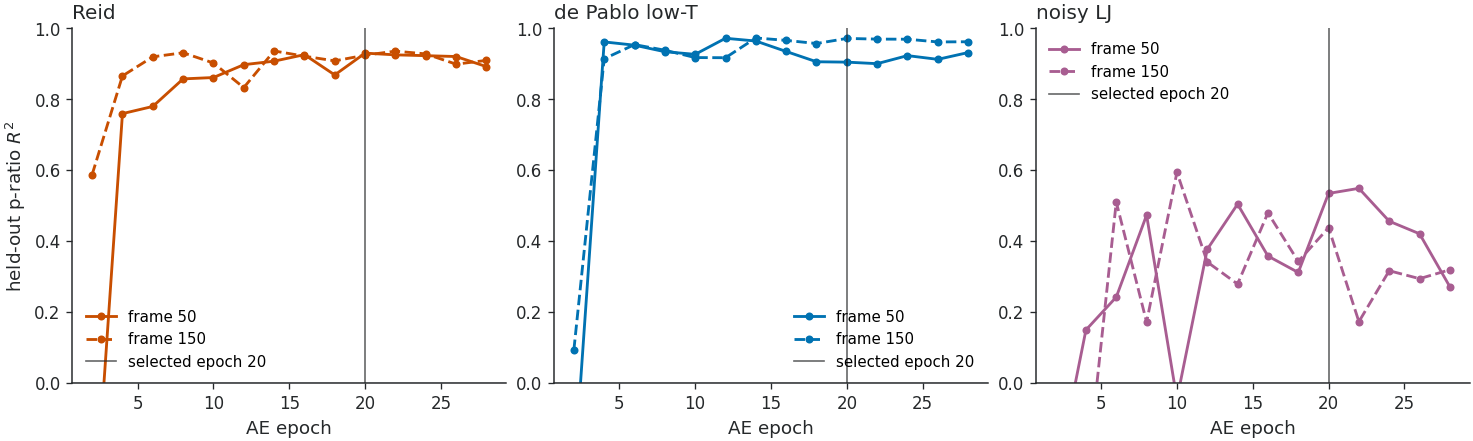

In [31]:
history = result['ae_history']
selection_column = 'val_ae_min_source_p_ratio_r2_sum_50_150'
selection_rows = history.reindex(columns=['epoch', selection_column]).dropna()
selected_epoch = int(selection_rows.loc[selection_rows[selection_column].idxmax(), 'epoch']) if not selection_rows.empty else None
fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.1 * len(DATASETS), 3.7), constrained_layout=True, squeeze=False)
for ax, (source_key, (label, _)) in zip(axes[0], DATASETS.items()):
    for frame, linestyle in [(50, '-'), (150, '--')]:
        column = f'val_ae_source_{source_key}_p_ratio_r2_step_{frame}'
        rows = history.reindex(columns=['epoch', column]).dropna()
        if not rows.empty:
            ax.plot(rows.epoch, rows[column], color=dataset_color(source_key), ls=linestyle,
                    marker='o', markersize=3.8, lw=1.7, label=f'frame {frame}')
    ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
    if selected_epoch is not None:
        ax.axvline(selected_epoch, color=PAPER_COLORS['ink'], lw=1.0, alpha=.7, label=f'selected epoch {selected_epoch}')
    ax.set_title(label, loc='left')
    ax.set_ylim(0, 1)
    style_axes(ax, xlabel='AE epoch', ylabel='held-out p-ratio $R^2$' if ax is axes[0, 0] else None, legend=True)
plt.show()

## Optimization diagnostics


/home/alexz/Documents/course_project/src/lss/plotting.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="best")


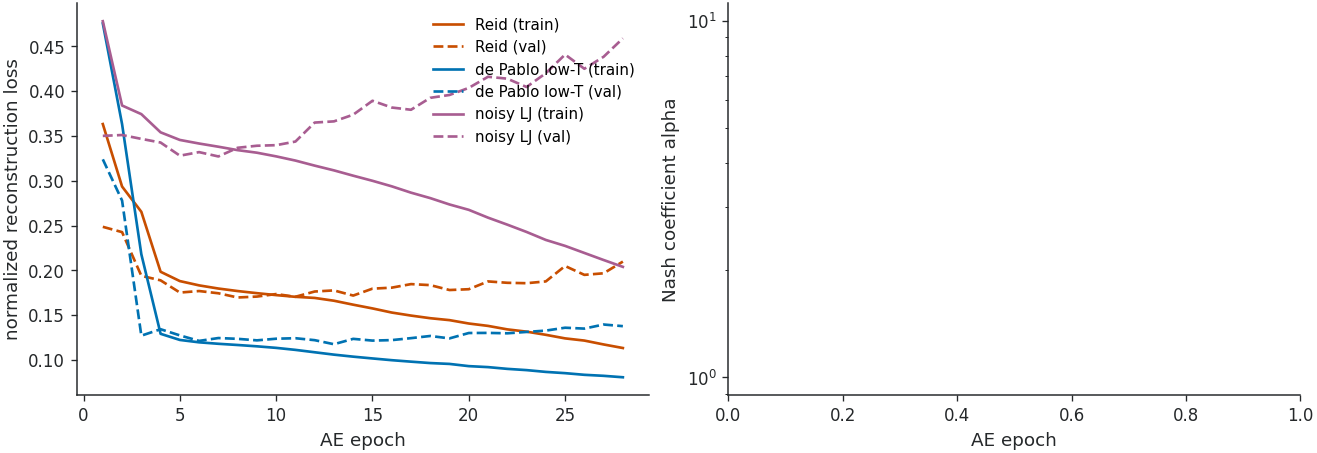

,epoch
18,19
19,20
20,21
21,22
22,23
23,24
24,25
25,26
26,27
27,28


In [32]:
history = result['ae_history']
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.8), constrained_layout=True)
for source_key, (label, _) in DATASETS.items():
    color = dataset_color(source_key)
    for split, linestyle in [('train', '-'), ('val', '--')]:
        column = f'{split}_source_{source_key}_reconstruction'
        rows = history.reindex(columns=['epoch', column]).dropna()
        if not rows.empty:
            axes[0].plot(rows.epoch, rows[column], color=color, ls=linestyle, lw=1.6, label=f'{label} ({split})')
    alpha_column = f'train_nash_alpha_{source_key}'
    alpha_rows = history.reindex(columns=['epoch', alpha_column]).dropna()
    if not alpha_rows.empty:
        axes[1].plot(alpha_rows.epoch, alpha_rows[alpha_column], color=color, marker='o', markersize=3.5, lw=1.5, label=label)
style_axes(axes[0], xlabel='AE epoch', ylabel='normalized reconstruction loss', legend=True)
style_axes(axes[1], xlabel='AE epoch', ylabel='Nash coefficient alpha', legend=True)
axes[1].set_yscale('log')
plt.show()
diagnostic_columns = [column for column in history if column == 'epoch' or column.startswith('train_nash_cosine_') or column in {'train_nash_residual', 'train_nash_min_task_projection', 'train_nash_fallback_rate'}]
display(history[diagnostic_columns].tail(10))


## Held-out reconstruction ceiling


,source,frame,n,p_ratio_r2,position_mse
0,depablo_low_temp,10,140,0.6552,0.0
1,depablo_low_temp,20,140,0.8176,0.0
2,depablo_low_temp,30,140,0.8936,0.0
3,depablo_low_temp,40,140,0.9322,0.0
4,depablo_low_temp,50,140,0.9513,0.0
5,depablo_low_temp,60,140,0.9610,0.0
6,depablo_low_temp,70,140,0.9667,0.0
7,depablo_low_temp,80,140,0.9711,0.0
8,depablo_low_temp,90,140,0.9747,0.0
9,depablo_low_temp,100,140,0.9778,0.0


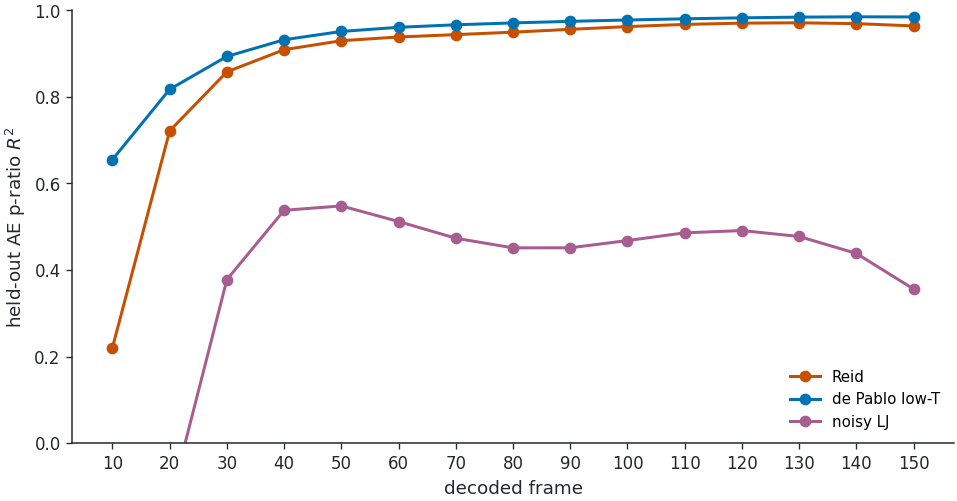

In [33]:
HELDOUT_RECONSTRUCTION_FRAMES = list(range(10, 151, 10))
ceiling_rows, _ = evaluate_autoencoder_reconstruction_horizons(
    result['ae'], result['test_data'], cfg=result['params'],
    normalizers=result['normalizers'], dataset=result['label'], split_name='test',
    rollout_steps=HELDOUT_RECONSTRUCTION_FRAMES, device=DEVICE,
)
ceiling_summary = []
for (source_key, steps), rows in ceiling_rows.groupby(['source', 'rollout_steps'], sort=True):
    rows = rows.dropna(subset=['true_p_ratio', 'pred_p_ratio'])
    ceiling_summary.append({
        'source': source_key, 'frame': int(steps), 'n': len(rows),
        'p_ratio_r2': r2_score(rows.true_p_ratio, rows.pred_p_ratio) if len(rows) > 1 else np.nan,
        'position_mse': rows.final_pos_mse.mean(),
    })
ceiling_summary = pd.DataFrame(ceiling_summary)
display(ceiling_summary.round(4))
fig, ax = plt.subplots(figsize=(8.0, 4.2), constrained_layout=True)
for source_key, (label, _) in DATASETS.items():
    rows = ceiling_summary.query('source == @source_key').sort_values('frame')
    ax.plot(rows.frame, rows.p_ratio_r2, marker='o', markersize=6, lw=1.8, color=dataset_color(source_key), label=label)
ax.axhline(0, color=PAPER_COLORS['slate'], lw=.8)
ax.set_xticks(HELDOUT_RECONSTRUCTION_FRAMES)
ax.set_ylim(0, 1)
style_axes(ax, xlabel='decoded frame', ylabel='held-out AE p-ratio $R^2$', legend=True)
plt.show()


## Latent encoding


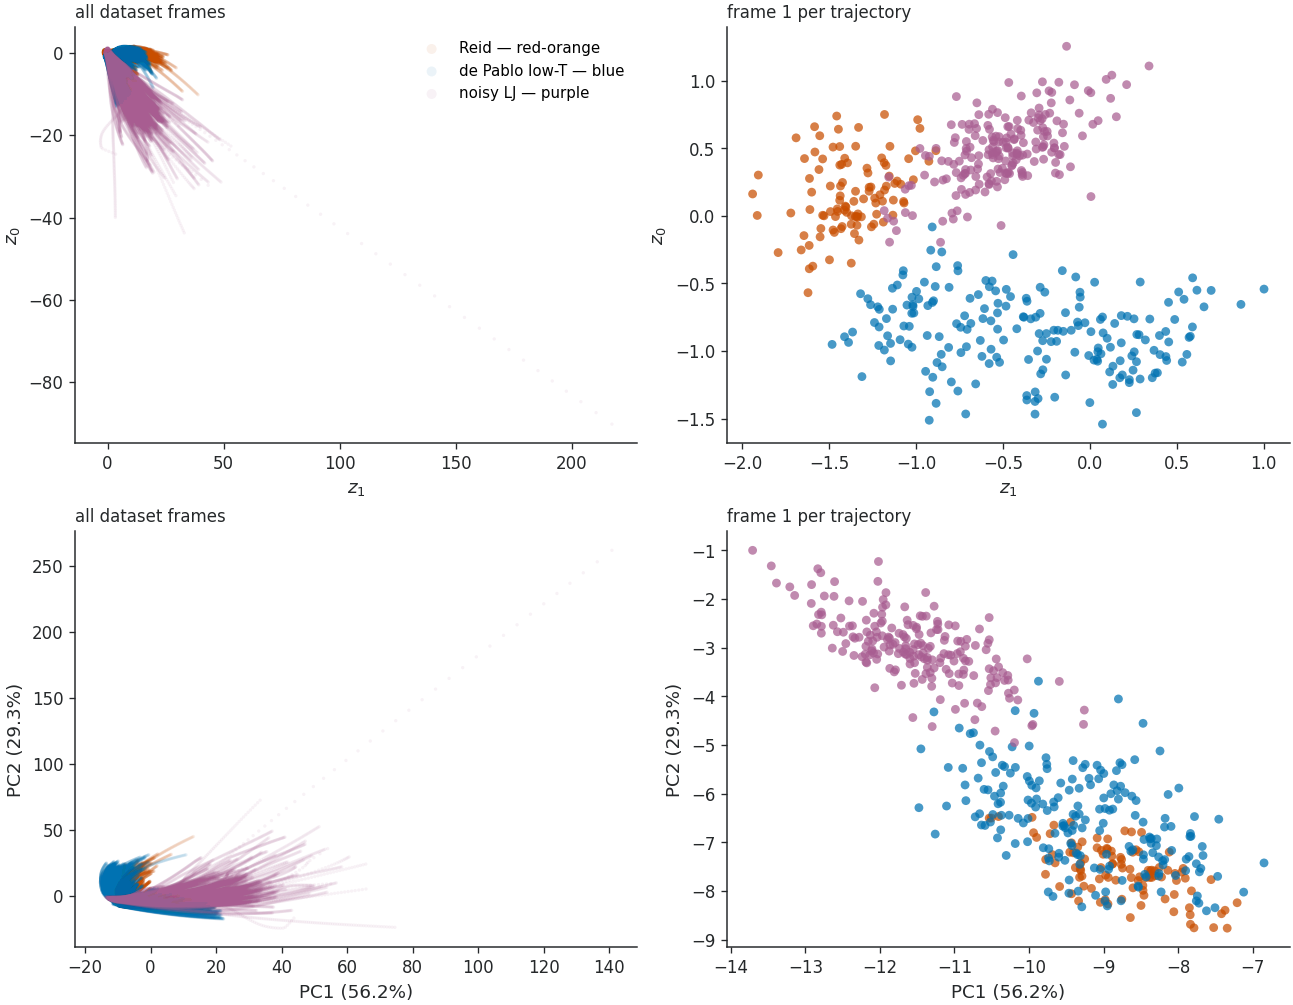

In [34]:
latent_sims = result['train_data'] + result['val_data'] + result['test_data']
latent_index = make_frame_index(latent_sims, frame_skip=1, include_last=True)
latent_chunks, latent_metadata = [], []
normalizers = result['normalizers']
node_mean = normalizers['node_feature_mean'].to(DEVICE)
node_std = normalizers['node_feature_std'].to(DEVICE)
edge_mean = normalizers['edge_mean'].to(DEVICE)
edge_std = normalizers['edge_std'].to(DEVICE)
ref_edge_mean = normalizers.get('ref_edge_mean', normalizers['edge_mean']).to(DEVICE)
ref_edge_std = normalizers.get('ref_edge_std', normalizers['edge_std']).to(DEVICE)
result['ae'].eval()
with torch.no_grad():
    for rows in iter_batches(latent_index, BATCH_GRAPHS, shuffle=False):
        batch_data = batch_delta_graphs(
            latent_sims, rows, pos_dim=2, device=DEVICE,
            node_feature_mode=result['params']['node_feature_mode'],
            edge_mode=result['params']['edge_mode'],
        )
        node_feature = (batch_data['node_feature'] - node_mean) / node_std
        edge_attr = (batch_data['edge_attr'] - edge_mean) / edge_std
        ref_edge_attr = (batch_data['ref_edge_attr'] - ref_edge_mean) / ref_edge_std
        z, _ = result['ae'].encode(
            node_feature, batch_data['ref_pos'], edge_attr, ref_edge_attr,
            batch_data['edge_index'], batch_data['batch'],
        )
        latent_chunks.append(z.detach().cpu().numpy())
        latent_metadata.extend(
            (sim_index, str(latent_sims[sim_index][0].source_name), frame)
            for sim_index, frame in rows
        )
latent_matrix = np.concatenate(latent_chunks, axis=0)
latent_frame = pd.DataFrame(latent_metadata, columns=['trajectory', 'source', 'frame'])
latent_columns = [f'z{index}' for index in range(latent_matrix.shape[1])]
latent_frame[latent_columns] = latent_matrix
latent_center = latent_matrix.mean(axis=0, keepdims=True)
_, singular_values, components = np.linalg.svd(latent_matrix - latent_center, full_matrices=False)
latent_projection = (latent_matrix - latent_center) @ components[:2].T
latent_frame[['pc1', 'pc2']] = latent_projection
explained = singular_values[:2] ** 2 / np.maximum((singular_values ** 2).sum(), 1e-12)
color_names = {'reid': 'red-orange', 'depablo_low_temp': 'blue', 'lj_noisy': 'purple'}

fig, axes = plt.subplots(2, 2, figsize=(10.8, 8.4), constrained_layout=True)
views = [
    (axes[0, 0], latent_frame, 'z1', 'z0', 'all dataset frames', '$z_1$', '$z_0$', 4, .08),
    (axes[0, 1], latent_frame.query('frame == 1'), 'z1', 'z0', 'frame 1 per trajectory', '$z_1$', '$z_0$', 28, .72),
    (axes[1, 0], latent_frame, 'pc1', 'pc2', 'all dataset frames', f'PC1 ({explained[0]:.1%})', f'PC2 ({explained[1]:.1%})', 4, .08),
    (axes[1, 1], latent_frame.query('frame == 1'), 'pc1', 'pc2', 'frame 1 per trajectory', f'PC1 ({explained[0]:.1%})', f'PC2 ({explained[1]:.1%})', 28, .72),
]
for view_index, (ax, view_rows, x, y, title, xlabel, ylabel, size, alpha) in enumerate(views):
    for source_key, (label, _) in DATASETS.items():
        rows = view_rows.query('source == @source_key')
        legend_label = f'{label} — {color_names[source_key]}'
        ax.scatter(rows[x], rows[y], s=size, alpha=alpha, color=dataset_color(source_key), edgecolor='none', rasterized=True, label=legend_label)
    ax.set_title(title, loc='left', fontsize=10)
    style_axes(ax, xlabel=xlabel, ylabel=ylabel, legend=False)
    if view_index == 0:
        ax.legend(frameon=False, markerscale=3.0, loc='best')
plt.show()


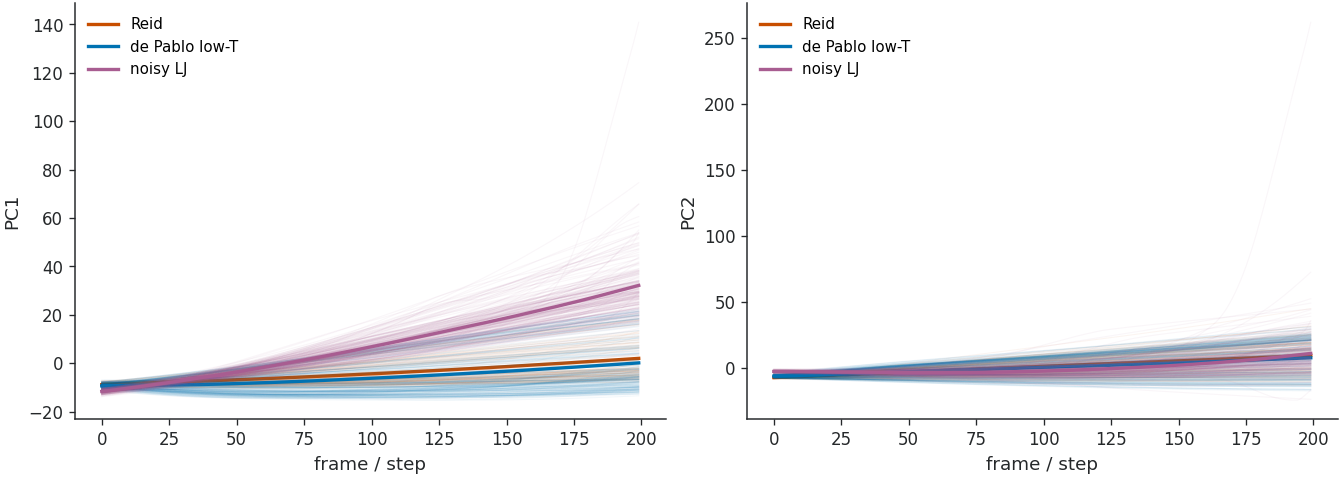

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0), constrained_layout=True)
for ax, component, ylabel in zip(axes, ['pc1', 'pc2'], ['PC1', 'PC2']):
    for source_key, (label, _) in DATASETS.items():
        source_rows = latent_frame.query('source == @source_key')
        color = dataset_color(source_key)
        for _, trajectory_rows in source_rows.groupby('trajectory', sort=False):
            ax.plot(trajectory_rows.frame, trajectory_rows[component], color=color, alpha=.055, lw=.65)
        frame_mean = source_rows.groupby('frame', as_index=False)[component].mean()
        ax.plot(frame_mean.frame, frame_mean[component], color=color, lw=2.0, label=label)
    style_axes(ax, xlabel='frame / step', ylabel=ylabel, legend=True)
plt.show()

## Latent correlations


,source,descriptor,PC1 |r|,PC2 |r|,best single latent,best single |r|,n
0,depablo_low_temp,deformation_magnitude,0.356,0.470,z1,0.858,40000
1,depablo_low_temp,endpoint_p_ratio,0.762,0.843,z5,0.895,39200
2,depablo_low_temp,final_p_ratio,0.761,0.790,z5,0.874,40000
3,depablo_low_temp,frame_progress,0.374,0.435,z1,0.840,40000
4,depablo_low_temp,x_strain,0.374,0.431,z1,0.837,40000
5,depablo_low_temp,y_strain,0.756,0.942,z5,0.947,40000
6,lj_noisy,deformation_magnitude,0.933,0.409,z2,0.933,40000
7,lj_noisy,endpoint_p_ratio,0.341,0.146,z4,0.465,39064
8,lj_noisy,final_p_ratio,0.224,0.178,z4,0.369,40000
9,lj_noisy,frame_progress,0.918,0.423,z2,0.918,40000


,source,descriptor,best single latent,highest single |r|,n
81,depablo_low_temp,y_strain,z5,0.947,40000
111,lj_noisy,y_strain,z2,0.945,40000
33,reid,y_strain,z5,0.901,20400


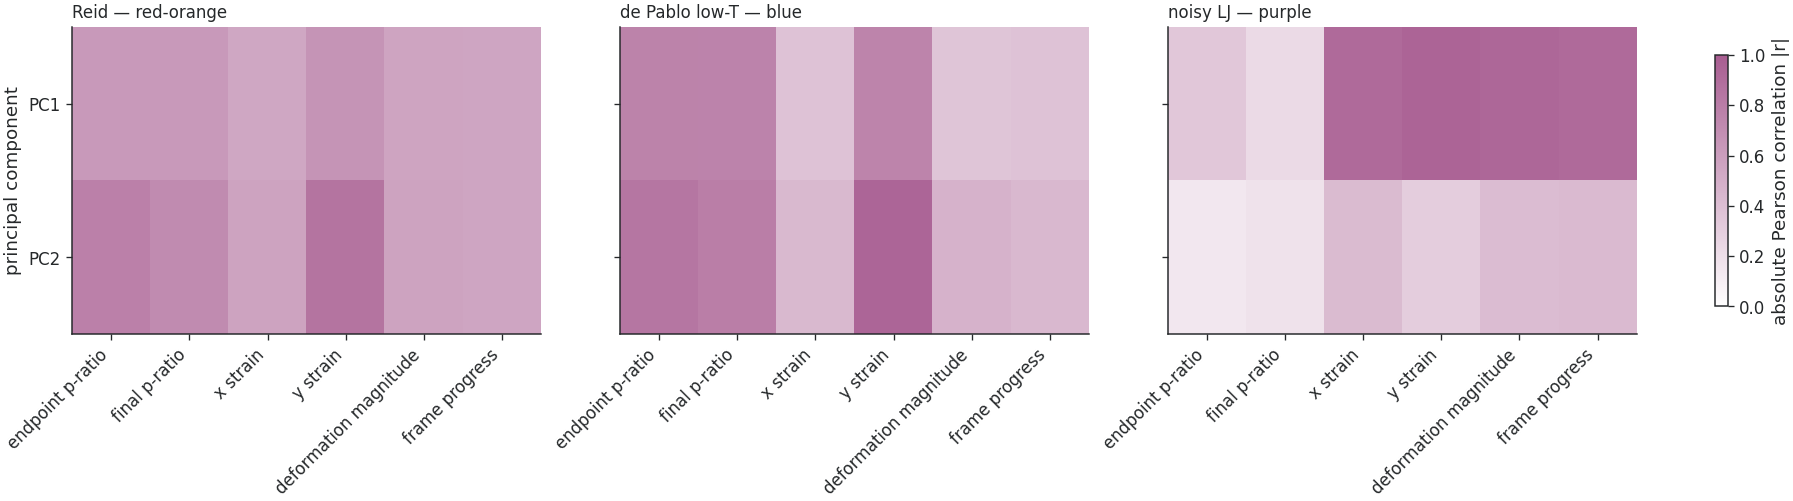

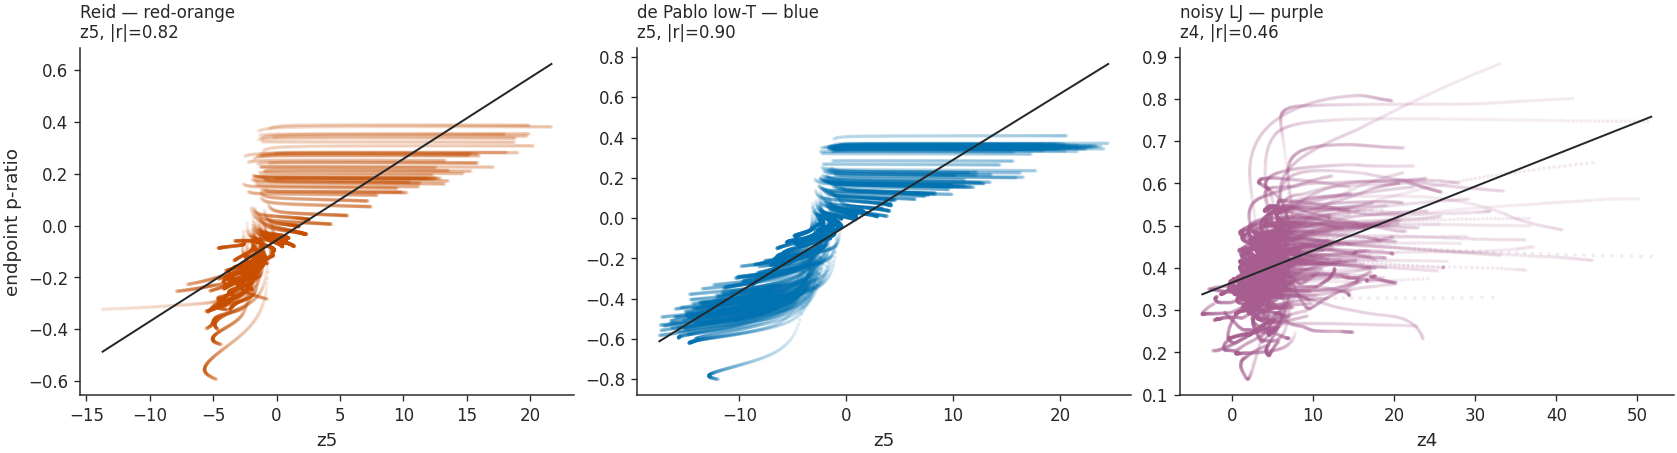

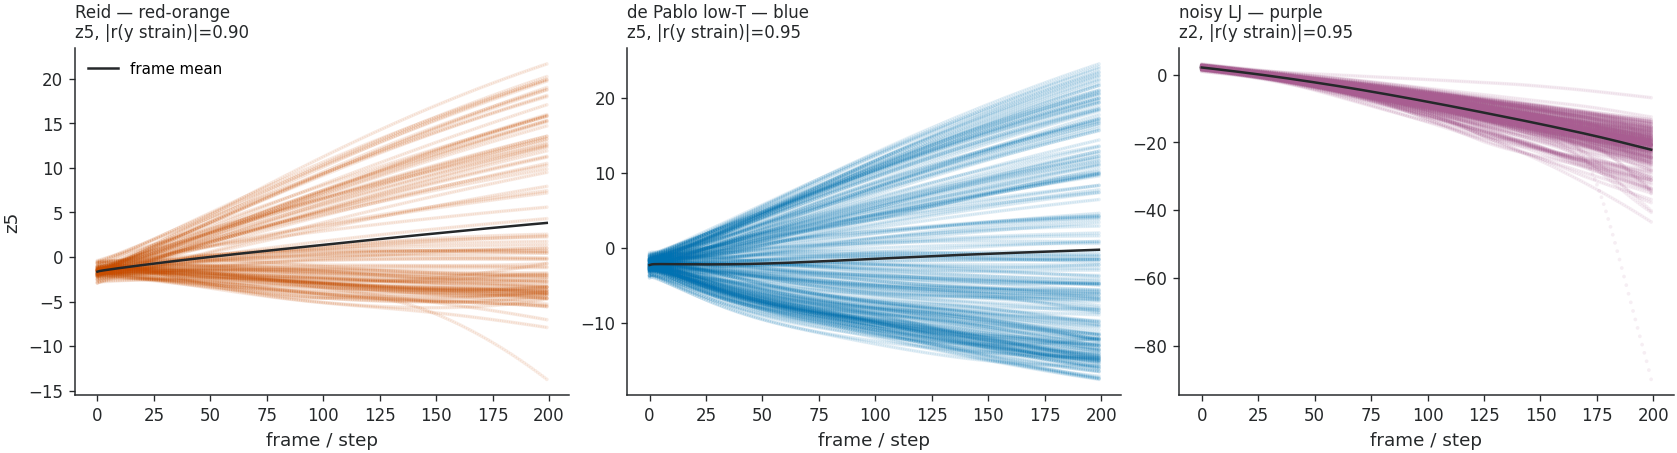

In [36]:
descriptor_chunks = []
for trajectory_index, sim in enumerate(latent_sims):
    reference = sim[0].x[:, :2].detach().cpu().numpy()
    positions = np.stack([graph.x[:, :2].detach().cpu().numpy() for graph in sim])
    displacement = positions - reference[None, :, :]
    side_indices = directional_side_indices_from_box(sim[0])
    delta_width = displacement[:, side_indices['right'], 0].mean(axis=1) - displacement[:, side_indices['left'], 0].mean(axis=1)
    delta_height = displacement[:, side_indices['top'], 1].mean(axis=1) - displacement[:, side_indices['bottom'], 1].mean(axis=1)
    reference_width = reference[side_indices['right'], 0].mean() - reference[side_indices['left'], 0].mean()
    reference_height = reference[side_indices['top'], 1].mean() - reference[side_indices['bottom'], 1].mean()
    x_strain = delta_width / max(abs(reference_width), 1e-12)
    y_strain = delta_height / max(abs(reference_height), 1e-12)
    deformation_magnitude = np.sqrt(x_strain ** 2 + y_strain ** 2)
    driven_displacement = np.maximum(np.abs(delta_width), np.abs(delta_height))
    endpoint_p_ratio = np.full(len(sim), np.nan)
    valid_ratio = (np.abs(delta_width) > 1e-12) & (np.abs(delta_height) > 1e-12) & (driven_displacement >= 1e-3)
    x_driven = np.abs(delta_width) >= np.abs(delta_height)
    use_x = valid_ratio & x_driven
    use_y = valid_ratio & ~x_driven
    endpoint_p_ratio[use_x] = -delta_height[use_x] / delta_width[use_x]
    endpoint_p_ratio[use_y] = -delta_width[use_y] / delta_height[use_y]
    final_p_ratio = endpoint_p_ratio[np.flatnonzero(np.isfinite(endpoint_p_ratio))[-1]] if np.isfinite(endpoint_p_ratio).any() else np.nan
    descriptor_chunks.append(pd.DataFrame({
        'trajectory': trajectory_index, 'frame': np.arange(len(sim)),
        'delta_width': delta_width, 'delta_height': delta_height,
        'x_strain': x_strain, 'y_strain': y_strain,
        'deformation_magnitude': deformation_magnitude,
        'endpoint_p_ratio': endpoint_p_ratio, 'final_p_ratio': final_p_ratio,
        'frame_progress': np.arange(len(sim)) / max(len(sim) - 1, 1),
    }))
deformation_frame = pd.concat(descriptor_chunks, ignore_index=True)
latent_analysis = latent_frame.merge(deformation_frame, on=['trajectory', 'frame'], how='left', validate='one_to_one')

raw_latent_features = latent_columns
latent_features = raw_latent_features + ['pc1', 'pc2']
descriptor_columns = ['endpoint_p_ratio', 'final_p_ratio', 'x_strain', 'y_strain', 'deformation_magnitude', 'frame_progress']
correlation_rows = []
for source_key in DATASETS:
    source_rows = latent_analysis.query('source == @source_key')
    for latent_feature in latent_features:
        for descriptor in descriptor_columns:
            paired = source_rows[[latent_feature, descriptor]].replace([np.inf, -np.inf], np.nan).dropna()
            correlation = paired[latent_feature].corr(paired[descriptor]) if len(paired) > 2 else np.nan
            correlation_rows.append({
                'source': source_key, 'latent_feature': latent_feature,
                'descriptor': descriptor, 'pearson_r': correlation, 'n': len(paired),
            })
correlation_frame = pd.DataFrame(correlation_rows)
correlation_frame['abs_r'] = correlation_frame.pearson_r.abs()
raw_correlation_frame = correlation_frame.query('latent_feature in @raw_latent_features')
best_single = raw_correlation_frame.loc[raw_correlation_frame.groupby(['source', 'descriptor']).abs_r.idxmax()].copy()
pc_correlations = correlation_frame.query("latent_feature in ['pc1', 'pc2']").pivot(index=['source', 'descriptor'], columns='latent_feature', values='abs_r').reset_index()
pc_and_best = pc_correlations.merge(
    best_single[['source', 'descriptor', 'latent_feature', 'abs_r', 'n']].rename(columns={'latent_feature': 'best single latent', 'abs_r': 'best single |r|'}),
    on=['source', 'descriptor'], how='left', validate='one_to_one',
).rename(columns={'pc1': 'PC1 |r|', 'pc2': 'PC2 |r|'})
strongest_by_dataset = best_single.loc[best_single.groupby('source').abs_r.idxmax()]
best_y_strain = best_single.query("descriptor == 'y_strain'").copy()
display(pc_and_best.sort_values(['source', 'descriptor']).round(3))
display(strongest_by_dataset[['source', 'descriptor', 'latent_feature', 'abs_r', 'n']].rename(columns={'latent_feature': 'best single latent', 'abs_r': 'highest single |r|'}).sort_values('source').round(3))

descriptor_labels = {
    'endpoint_p_ratio': 'endpoint p-ratio', 'final_p_ratio': 'final p-ratio',
    'x_strain': 'x strain', 'y_strain': 'y strain',
    'deformation_magnitude': 'deformation magnitude', 'frame_progress': 'frame progress',
}
editorial_absolute = LinearSegmentedColormap.from_list(
    'editorial_absolute', ['white', PAPER_COLORS['purple']]
)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(15.0, 4.2), sharey=True, constrained_layout=True)
for ax, (source_key, (label, _)) in zip(axes, DATASETS.items()):
    matrix = correlation_frame.query('source == @source_key and latent_feature in [\"pc1\", \"pc2\"]').pivot(index='latent_feature', columns='descriptor', values='abs_r').reindex(index=['pc1', 'pc2'], columns=descriptor_columns)
    image = ax.imshow(matrix.to_numpy(), vmin=0, vmax=1, cmap=editorial_absolute, aspect='auto')
    ax.set_title(f'{label} — {color_names[source_key]}', loc='left', fontsize=10)
    ax.set_xticks(range(len(descriptor_columns)), [descriptor_labels[column] for column in descriptor_columns], rotation=45, ha='right')
    ax.set_yticks(range(2), ['PC1', 'PC2'])
    ax.grid(False)
axes[0].set_ylabel('principal component')
fig.colorbar(image, ax=axes, shrink=.82, label='absolute Pearson correlation |r|')
plt.show()

fig, axes = plt.subplots(1, len(DATASETS), figsize=(14.0, 3.8), constrained_layout=True)
for ax, (source_key, (label, _)) in zip(axes, DATASETS.items()):
    best_row = best_single.query("source == @source_key and descriptor == 'endpoint_p_ratio'").iloc[0]
    feature = best_row.latent_feature
    rows = latent_analysis.query('source == @source_key')[[feature, 'endpoint_p_ratio']].dropna()
    ax.scatter(rows[feature], rows.endpoint_p_ratio, s=5, alpha=.12, color=dataset_color(source_key), edgecolor='none', rasterized=True)
    if len(rows) > 1:
        slope, intercept = np.polyfit(rows[feature], rows.endpoint_p_ratio, 1)
        x_line = np.linspace(rows[feature].min(), rows[feature].max(), 100)
        ax.plot(x_line, slope * x_line + intercept, color=PAPER_COLORS['ink'], lw=1.2)
    ax.set_title(f'{label} — {color_names[source_key]}\n{feature}, |r|={best_row.abs_r:.2f}', loc='left', fontsize=10)
    style_axes(ax, xlabel=feature, ylabel='endpoint p-ratio' if ax is axes[0] else None)
plt.show()

fig, axes = plt.subplots(1, len(DATASETS), figsize=(14.0, 3.8), constrained_layout=True)
for ax, (source_key, (label, _)) in zip(axes, DATASETS.items()):
    best_row = best_y_strain.query('source == @source_key').iloc[0]
    feature = best_row.latent_feature
    rows = latent_analysis.query('source == @source_key')[[feature, 'frame']].dropna()
    ax.scatter(rows.frame, rows[feature], s=5, alpha=.10, color=dataset_color(source_key), edgecolor='none', rasterized=True)
    frame_mean = rows.groupby('frame', as_index=False)[feature].mean()
    ax.plot(frame_mean.frame, frame_mean[feature], color=PAPER_COLORS['ink'], lw=1.5, label='frame mean')
    ax.set_title(f'{label} — {color_names[source_key]}\n{feature}, |r(y strain)|={best_row.abs_r:.2f}', loc='left', fontsize=10)
    style_axes(ax, xlabel='frame / step', ylabel=feature if ax is axes[0] else None, legend=ax is axes[0])
plt.show()


## Frozen-AE autoregressive propagator


{'propagator_config_hash': '5ebcecfe2219b62d', 'cache': '/home/alexz/Documents/course_project/notebooks/results/08_four_source_standard_ae/propagator_cache/latent_5ebcecfe2219b62d.pt', 'cached': True, 'force_train': True, 'stride': 1, 'observed_frames': 3, 'training_unroll': 5, 'hidden_size': 96, 'context_pool': 'mean', 'context_dim': 16, 'prediction': 'latent acceleration correction'}



=== three-source standard autoencoder ===
          source                                                                                                 path  total  train  reserved_train_pool  val  test
            reid                                         /home/alexz/Documents/course_project/data/reid_200_frames.pt    102     30                   30   30    42
depablo_low_temp                                  /home/alexz/Documents/course_project/data/depablo-near-zero-temp.pt    200     30                   30   30   140
        lj_noisy /home/alexz/Documents/course_project/data/lj-noisy-eps0.01-sigma1.0-cutoff1.122_200sims_200frames.pt    200     60                   60   30   110
source-mixed AE coverage: {'reid': {'trajectories': 30, 'frames': 4500}, 'depablo_low_temp': {'trajectories': 30, 'frames': 4500}, 'lj_noisy': {'trajectories': 60, 'frames': 9000}}
autoencoder
loaded pretrained AE: /home/alexz/Documents/course_project/notebooks/results/08_four_source_standard_ae/cach

,epoch,train_loss,val_loss,train_dz_mse_norm,val_dz_mse_norm,train_source_lj_noisy_loss_norm,train_source_reid_loss_norm,train_source_depablo_low_temp_loss_norm,val_source_reid_loss_norm,val_source_depablo_low_temp_loss_norm,val_source_lj_noisy_loss_norm
0,1,0.00512,0.00349,0.00512,0.00349,0.00956,0.00050,0.00086,0.00051,0.00085,0.00905
1,2,0.00383,0.00297,0.00383,0.00297,0.00699,0.00051,0.00084,0.00047,0.00079,0.00759
2,3,0.00358,0.00296,0.00358,0.00296,0.00655,0.00047,0.00077,0.00046,0.00074,0.00765
3,4,0.00350,0.00288,0.00350,0.00288,0.00643,0.00044,0.00070,0.00045,0.00068,0.00747
4,5,0.00342,0.00277,0.00342,0.00277,0.00632,0.00041,0.00062,0.00042,0.00059,0.00724
5,6,0.00335,0.00271,0.00335,0.00271,0.00624,0.00039,0.00053,0.00041,0.00051,0.00715
6,7,0.00332,0.00269,0.00332,0.00269,0.00622,0.00038,0.00047,0.00040,0.00047,0.00715
7,8,0.00329,0.00268,0.00329,0.00268,0.00618,0.00037,0.00044,0.00040,0.00045,0.00714
8,9,0.00325,0.00267,0.00325,0.00267,0.00611,0.00036,0.00041,0.00038,0.00042,0.00716
9,10,0.00324,0.00265,0.00324,0.00265,0.00610,0.00035,0.00039,0.00038,0.00041,0.00711


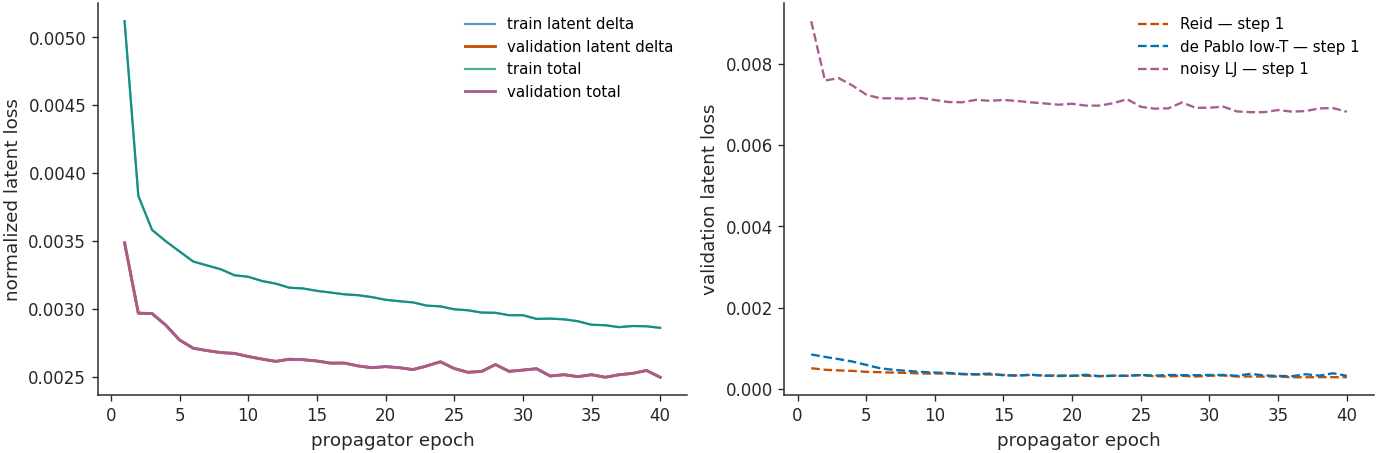

In [37]:
propagator_config = {
    'max_train_transitions_per_sim': MAX_FRAMES_PER_SIM - 3,
    'max_epochs': PROPAGATOR_MAX_EPOCHS, 'patience': PROPAGATOR_PATIENCE,
    'lr': 1e-4, 'weight_decay': 1e-5, 'hidden_size': 96,
    'model': 'history_mlp', 'objective': 'kinematic_multistep', 'loss': 'delta',
    'step_stride': 1, 'initial_velocity': 'three_frames', 'rollout_history_frames': 3,
    'multistep_horizons': [1], #'truncated_rollout_horizon': 5,
    'mix_sources': True, 'source_loss_reduction': 'pooled',
    'train_trajectories_per_source': TRAIN_COUNTS,
    'val_trajectories_per_source': {key: VAL_PER_SOURCE for key in DATASETS},
    'use_static_context': True, 'context_pool': 'mean', 'context_dim': 16,
    'frozen_latent_cache_dir': str(FROZEN_LATENT_CACHE_DIR),
    'context_include_temperature': False, 'context_include_source_id': False,
    'rollout_eval_every_epoch': False,
    'rollout_eval_horizons': [10, 50, 100], 'rollout_eval_sims_per_source': 10,
    'rollout_eval_sources': tuple(DATASETS),
    'checkpoint_metric': None, 'checkpoint_mode': 'min',
}
propagator_experiment_config = {
    'ae_config': ae_config, 'propagator_config': propagator_config,
    'dataset_name': source['dataset_name'], 'split_seed': SEED,
    'split_stratify_temperature': False, 'model_seed': SEED,
    'device': str(DEVICE), 'pos_dim': 2, 'batch_graphs': BATCH_GRAPHS, 'frame_skip': 1,
    'train_frame_start_order': 0, 'coordinate_normalization': 'position_normalization',
    'edge_mode': 'compact_stored', 'p_ratio_estimator': 'endpoint',
    'static_context_use_physical_reference': True,
    'rollout_steps_grid': ROLLOUT_STEPS, 'rollout_final_eval_sims_per_source': VAL_PER_SOURCE,
    'should_rollout': True, 'should_train_propagator': True,
    'pretrained_ae_cache_path': str(AE_CACHE),
    'pretrained_ae_config_keys': [
        'split_seed', 'coordinate_normalization', 'edge_mode', 'pos_dim',
        'latent_dim', 'latent_tokens', 'hidden_size', 'autoencoder_model',
        'edge_feature_dim', 'node_feature_mode', 'ae_target_mode',
        'ae_max_train_frames_per_sim', 'ae_max_val_frames_per_sim',
    ],
    'pretrained_ae_require_matching_normalizers': True,
    'pretrained_ae_require_matching_config': True,
    'force_train_autoencoder': False, 'force_train': FORCE_TRAIN_PROPAGATOR,
    'cache_require_matching_config': True, 'cache_dir': PROPAGATOR_CACHE_DIR,
    'early_stop_min_delta': 1e-5,
}
PROPAGATOR_CONFIG_HASH = latent_experiment_cache_key(source, propagator_experiment_config)
PROPAGATOR_CACHE = PROPAGATOR_CACHE_DIR/f'latent_{PROPAGATOR_CONFIG_HASH}.pt'
print({
    'propagator_config_hash': PROPAGATOR_CONFIG_HASH, 'cache': str(PROPAGATOR_CACHE),
    'cached': PROPAGATOR_CACHE.is_file(), 'force_train': FORCE_TRAIN_PROPAGATOR,
    'stride': 1, 'observed_frames': 3, 'training_unroll': 5,
    'hidden_size': 96, 'context_pool': 'mean', 'context_dim': 16,
    'prediction': 'latent acceleration correction',
})
seed_everything(SEED)
prop_result = run_latent_experiment(source, propagator_experiment_config, device=DEVICE)
dyn_history = prop_result['dyn_history'].copy()
history_columns = [column for column in [
    'epoch', 'train_loss', 'val_loss', 'train_dz_mse_norm', 'val_dz_mse_norm',
    'train_first_step_loss_norm', 'val_first_step_loss_norm',
    'train_rollout_step_5_loss_norm', 'val_rollout_step_5_loss_norm',
] if column in dyn_history]
history_columns += [column for column in dyn_history if column.startswith(('train_source_', 'val_source_'))]
display(dyn_history[history_columns].round(5))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), constrained_layout=True)
loss_pairs = [
    ('train_first_step_loss_norm', 'val_first_step_loss_norm', 'one-step'),
    ('train_rollout_step_5_loss_norm', 'val_rollout_step_5_loss_norm', 'step 5'),
    ('train_dz_mse_norm', 'val_dz_mse_norm', 'latent delta'),
    ('train_loss', 'val_loss', 'total'),
]
plotted = set()
for train_column, val_column, label in loss_pairs:
    if train_column in dyn_history and train_column not in plotted:
        axes[0].plot(dyn_history.epoch, dyn_history[train_column], lw=1.3, alpha=.70, label=f'train {label}')
        plotted.add(train_column)
    if val_column in dyn_history and val_column not in plotted:
        axes[0].plot(dyn_history.epoch, dyn_history[val_column], lw=1.7, label=f'validation {label}')
        plotted.add(val_column)
style_axes(axes[0], xlabel='propagator epoch', ylabel='normalized latent loss', legend=True)
for source_key, (label, _) in DATASETS.items():
    color = dataset_color(source_key)
    first_column = f'val_source_{source_key}_first_step_loss_norm'
    if first_column not in dyn_history:
        first_column = f'val_source_{source_key}_loss_norm'
    fifth_column = f'val_source_{source_key}_rollout_step_5_loss_norm'
    if first_column in dyn_history:
        axes[1].plot(dyn_history.epoch, dyn_history[first_column], color=color, ls='--', lw=1.4, label=f'{label} — step 1')
    if fifth_column in dyn_history:
        axes[1].plot(dyn_history.epoch, dyn_history[fifth_column], color=color, lw=1.8, label=f'{label} — step 5')
style_axes(axes[1], xlabel='propagator epoch', ylabel='validation latent loss', legend=True)
plt.show()


## Held-out autoregressive rollout


,method,source,rollout_steps,trajectories,p_ratio_r2,p_ratio_mse,position_mse,position_error_fraction,position_r2
3,frozen AE ceiling,depablo_low_temp,10,30,0.7506,0.0205,0.0,0.5008,0.4992
5,frozen AE ceiling,depablo_low_temp,50,30,0.9541,0.0051,0.0,0.0585,0.9415
7,frozen AE ceiling,depablo_low_temp,100,30,0.9769,0.0027,0.0,0.0590,0.9410
9,frozen AE ceiling,depablo_low_temp,150,30,0.9897,0.0013,0.0,0.0663,0.9337
13,frozen AE ceiling,lj_noisy,10,30,-0.5852,0.0076,0.0,0.1919,0.8081
15,frozen AE ceiling,lj_noisy,50,30,0.6428,0.0037,0.0,0.1657,0.8343
17,frozen AE ceiling,lj_noisy,100,30,0.6296,0.0048,0.0,0.1993,0.8007
19,frozen AE ceiling,lj_noisy,150,30,0.5269,0.0069,0.0,0.2481,0.7519
23,frozen AE ceiling,reid,10,30,0.1510,0.0294,0.0,0.1926,0.8074
25,frozen AE ceiling,reid,50,30,0.9190,0.0038,0.0,0.1343,0.8657


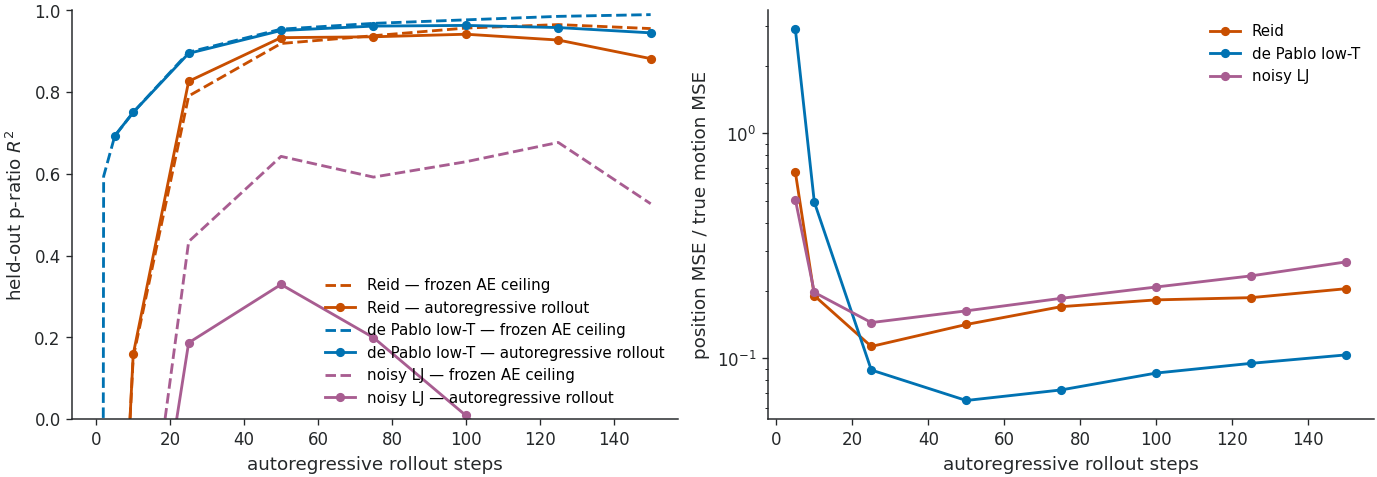

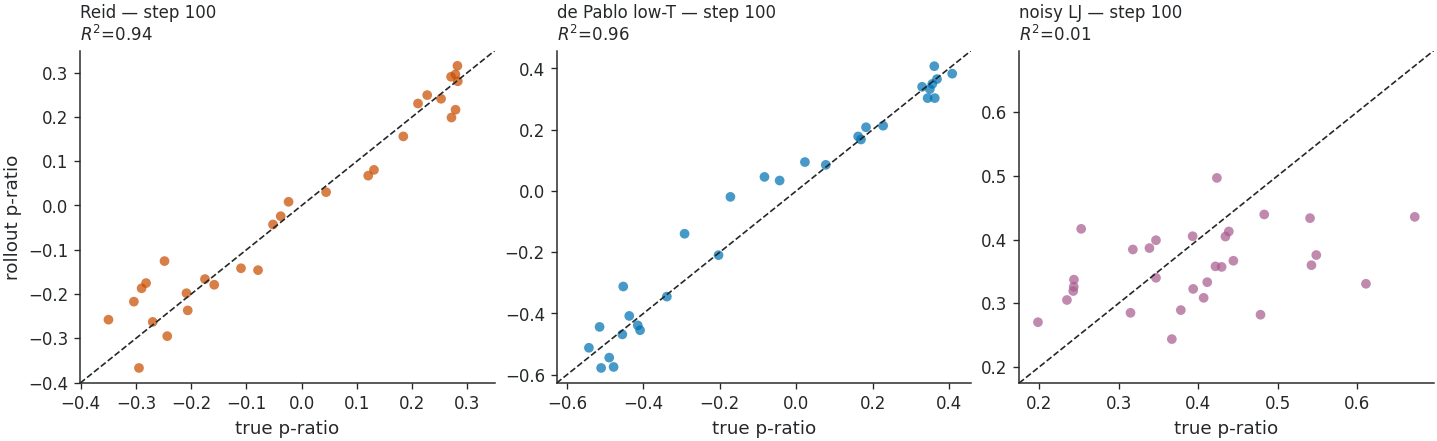

In [38]:
def summarize_rollouts(rows, method):
    records = []
    for (source_key, step), group in rows.groupby(['source', 'rollout_steps'], sort=True):
        valid = group[['true_p_ratio', 'pred_p_ratio']].dropna()
        position_mse = float(group.final_pos_mse.mean())
        motion_mse = float(group.initial_to_target_mse.mean())
        error_fraction = position_mse / motion_mse if motion_mse > 0 else np.nan
        records.append({
            'method': method, 'source': source_key, 'rollout_steps': int(step),
            'trajectories': len(group),
            'p_ratio_r2': r2_score(valid.true_p_ratio, valid.pred_p_ratio) if len(valid) > 1 else np.nan,
            'p_ratio_mse': np.mean((valid.true_p_ratio - valid.pred_p_ratio) ** 2) if len(valid) else np.nan,
            'position_mse': position_mse, 'position_error_fraction': error_fraction,
            'position_r2': np.clip(1.0 - error_fraction, 0.0, 1.0) if np.isfinite(error_fraction) else np.nan,
        })
    return pd.DataFrame(records)

evaluation_sources = tuple(DATASETS)
test_rollout_rows = prop_result['rollout_rows'].query("split == 'test' and source in @evaluation_sources").copy()
test_ceiling_rows = prop_result['ae_reconstruction_rows'].query("split == 'test' and source in @evaluation_sources").copy()
rollout_metrics = pd.concat([
    summarize_rollouts(test_ceiling_rows, 'frozen AE ceiling'),
    summarize_rollouts(test_rollout_rows, 'autoregressive rollout'),
], ignore_index=True)
display(rollout_metrics.query('rollout_steps in [10, 50, 100, 150]').round(4))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), constrained_layout=True)
for source_key, (label, _) in DATASETS.items():
    color = dataset_color(source_key)
    for method, linestyle, marker in [('frozen AE ceiling', '--', None), ('autoregressive rollout', '-', 'o')]:
        rows = rollout_metrics.query('source == @source_key and method == @method').sort_values('rollout_steps')
        axes[0].plot(rows.rollout_steps, rows.p_ratio_r2, color=color, ls=linestyle, marker=marker,
                     markersize=4.5, lw=1.7, label=f'{label} — {method}')
    rows = rollout_metrics.query("source == @source_key and method == 'autoregressive rollout'").sort_values('rollout_steps')
    axes[1].plot(rows.rollout_steps, rows.position_error_fraction, color=color, marker='o',
                 markersize=4.5, lw=1.7, label=label)
axes[0].set_ylim(0, 1)
style_axes(axes[0], xlabel='autoregressive rollout steps', ylabel='held-out p-ratio $R^2$', legend=True)
axes[1].set_yscale('log')
style_axes(axes[1], xlabel='autoregressive rollout steps', ylabel='position MSE / true motion MSE', legend=True)
plt.show()

scatter_step = 100
fig, axes = plt.subplots(1, len(DATASETS), figsize=(12.0, 3.7), constrained_layout=True)
for ax, (source_key, (label, _)) in zip(axes, DATASETS.items()):
    rows = test_rollout_rows.query('source == @source_key and rollout_steps == @scatter_step').dropna(subset=['true_p_ratio', 'pred_p_ratio'])
    ax.scatter(rows.true_p_ratio, rows.pred_p_ratio, s=34, alpha=.72, color=dataset_color(source_key), edgecolor='none')
    values = rows[['true_p_ratio', 'pred_p_ratio']].to_numpy(float).ravel()
    values = values[np.isfinite(values)]
    if len(values):
        lo, hi = values.min(), values.max(); pad = .05 * max(hi - lo, 1e-6)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], '--', color=PAPER_COLORS['ink'], lw=1.0)
        ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    score = r2_score(rows.true_p_ratio, rows.pred_p_ratio) if len(rows) > 1 else np.nan
    ax.set_title(f'{label} — step {scatter_step}\n$R^2$={score:.2f}', loc='left', fontsize=10)
    style_axes(ax, xlabel='true p-ratio', ylabel='rollout p-ratio' if ax is axes[0] else None)
plt.show()
